In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("praveengovi/emotions-dataset-for-nlp")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'emotions-dataset-for-nlp' dataset.
Path to dataset files: /kaggle/input/emotions-dataset-for-nlp


In [ ]:
import pandas as pd
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import os

In [ ]:


df = pd.read_csv(
    "/kaggle/input/emotions-dataset-for-nlp/train.txt",
    sep=";",
    names=["text", "emotion"]
)

df.head()

,text,emotion
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [ ]:
df["text_lower"] = df["text"].str.upper()

df[["text", "text_lower"]].head()

,text,text_lower
0,i didnt feel humiliated,I DIDNT FEEL HUMILIATED
1,i can go from feeling so hopeless to so damned...,I CAN GO FROM FEELING SO HOPELESS TO SO DAMNED...
2,im grabbing a minute to post i feel greedy wrong,IM GRABBING A MINUTE TO POST I FEEL GREEDY WRONG
3,i am ever feeling nostalgic about the fireplac...,I AM EVER FEELING NOSTALGIC ABOUT THE FIREPLAC...
4,i am feeling grouchy,I AM FEELING GROUCHY


In [ ]:
nltk.download('punkt') #tokenizer
nltk.download('stopwords') #stopwords
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
stop_words = set(stopwords.words('english'))
print(stop_words)
lemmatizer = WordNetLemmatizer()

{"won't", "she'd", 'hasn', "she'll", 'any', "hadn't", 'this', 'couldn', 'very', 'himself', 'weren', 'mustn', 'there', "i've", 'not', 'and', 'between', "don't", 'most', 'which', "we'd", 'i', "he's", 'itself', "wouldn't", 'their', "she's", "wasn't", 'does', 'hadn', 'won', 'with', 'own', 'needn', 'out', 'yours', 'such', 'because', 'aren', "we're", 'we', 'of', 'ma', 'ours', "isn't", 'doing', 'shouldn', 'all', 'about', "should've", "they're", "we've", 'each', 'while', 'wasn', 'my', 'just', 'some', 'they', 'an', 'but', 'his', 'in', 'had', 've', 'as', 'your', "he'll", 're', 'the', 'what', 'do', 'if', 'these', 'were', 'is', "haven't", 'above', 'few', 'our', "it'll", 'its', 'she', "you've", 'over', "that'll", 'are', 'd', 'both', "needn't", "mustn't", 'until', 'once', 'same', "he'd", "it'd", 'who', 'no', 'you', "i'd", 'he', 'that', 'didn', "they'll", "you're", 'ain', "they've", "couldn't", 'don', 'now', 'can', "they'd", 'than', 'haven', "it's", 'where', 'wouldn', "you'll", 'whom', 'will', 'be', 

In [ ]:
from nltk.tokenize import word_tokenize

def process_text(text):
    word_tokens = word_tokenize(text)
    filtered_tokens = [word for word in word_tokens if word.casefold() not in stop_words]
    lemmatized_tokens = [lemmatizer.lemmatize(token) for token in filtered_tokens]

    return {
        "Original_Text": text,
        "Word_Tokens": word_tokens,
        "Filtered_Tokens": filtered_tokens,
        "Lemmatized_Tokens": lemmatized_tokens
    }

results = df['text'].apply(process_text)
processed_df = pd.DataFrame(results.tolist())

processed_df.head()

,Original_Text,Word_Tokens,Filtered_Tokens,Lemmatized_Tokens
0,i didnt feel humiliated,"[i, didnt, feel, humiliated]","[didnt, feel, humiliated]","[didnt, feel, humiliated]"
1,i can go from feeling so hopeless to so damned...,"[i, can, go, from, feeling, so, hopeless, to, ...","[go, feeling, hopeless, damned, hopeful, aroun...","[go, feeling, hopeless, damned, hopeful, aroun..."
2,im grabbing a minute to post i feel greedy wrong,"[im, grabbing, a, minute, to, post, i, feel, g...","[im, grabbing, minute, post, feel, greedy, wrong]","[im, grabbing, minute, post, feel, greedy, wrong]"
3,i am ever feeling nostalgic about the fireplac...,"[i, am, ever, feeling, nostalgic, about, the, ...","[ever, feeling, nostalgic, fireplace, know, st...","[ever, feeling, nostalgic, fireplace, know, st..."
4,i am feeling grouchy,"[i, am, feeling, grouchy]","[feeling, grouchy]","[feeling, grouchy]"


In [ ]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

df["tokens"] = df["text"].apply(word_tokenize)

df["filtered_tokens"] = df["tokens"].apply(
    lambda tokens: [word for word in tokens if word.casefold() not in stop_words]
)

df[["tokens", "filtered_tokens"]].head()

,tokens,filtered_tokens
0,"[i, didnt, feel, humiliated]","[didnt, feel, humiliated]"
1,"[i, can, go, from, feeling, so, hopeless, to, ...","[go, feeling, hopeless, damned, hopeful, aroun..."
2,"[im, grabbing, a, minute, to, post, i, feel, g...","[im, grabbing, minute, post, feel, greedy, wrong]"
3,"[i, am, ever, feeling, nostalgic, about, the, ...","[ever, feeling, nostalgic, fireplace, know, st..."
4,"[i, am, feeling, grouchy]","[feeling, grouchy]"


In [ ]:
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

df["stemmed_tokens"] = df["tokens"].apply(
    lambda tokens: [stemmer.stem(word) for word in tokens]
)

df[["text", "stemmed_tokens"]].head(10)

,text,stemmed_tokens
0,i didnt feel humiliated,"[i, didnt, feel, humili]"
1,i can go from feeling so hopeless to so damned...,"[i, can, go, from, feel, so, hopeless, to, so,..."
2,im grabbing a minute to post i feel greedy wrong,"[im, grab, a, minut, to, post, i, feel, greedi..."
3,i am ever feeling nostalgic about the fireplac...,"[i, am, ever, feel, nostalg, about, the, firep..."
4,i am feeling grouchy,"[i, am, feel, grouchi]"
5,ive been feeling a little burdened lately wasn...,"[ive, been, feel, a, littl, burden, late, wasn..."
6,ive been taking or milligrams or times recomme...,"[ive, been, take, or, milligram, or, time, rec..."
7,i feel as confused about life as a teenager or...,"[i, feel, as, confus, about, life, as, a, teen..."
8,i have been with petronas for years i feel tha...,"[i, have, been, with, petrona, for, year, i, f..."
9,i feel romantic too,"[i, feel, romant, too]"


In [ ]:
from nltk.stem import WordNetLemmatizer
import nltk



lemmatizer = WordNetLemmatizer()

df["lemmatized_tokens"] = df["tokens"].apply(
    lambda tokens: [lemmatizer.lemmatize(word) for word in tokens]
)

df[["text", "stemmed_tokens", "lemmatized_tokens"]].head(10)

,text,stemmed_tokens,lemmatized_tokens
0,i didnt feel humiliated,"[i, didnt, feel, humili]","[i, didnt, feel, humiliated]"
1,i can go from feeling so hopeless to so damned...,"[i, can, go, from, feel, so, hopeless, to, so,...","[i, can, go, from, feeling, so, hopeless, to, ..."
2,im grabbing a minute to post i feel greedy wrong,"[im, grab, a, minut, to, post, i, feel, greedi...","[im, grabbing, a, minute, to, post, i, feel, g..."
3,i am ever feeling nostalgic about the fireplac...,"[i, am, ever, feel, nostalg, about, the, firep...","[i, am, ever, feeling, nostalgic, about, the, ..."
4,i am feeling grouchy,"[i, am, feel, grouchi]","[i, am, feeling, grouchy]"
5,ive been feeling a little burdened lately wasn...,"[ive, been, feel, a, littl, burden, late, wasn...","[ive, been, feeling, a, little, burdened, late..."
6,ive been taking or milligrams or times recomme...,"[ive, been, take, or, milligram, or, time, rec...","[ive, been, taking, or, milligram, or, time, r..."
7,i feel as confused about life as a teenager or...,"[i, feel, as, confus, about, life, as, a, teen...","[i, feel, a, confused, about, life, a, a, teen..."
8,i have been with petronas for years i feel tha...,"[i, have, been, with, petrona, for, year, i, f...","[i, have, been, with, petronas, for, year, i, ..."
9,i feel romantic too,"[i, feel, romant, too]","[i, feel, romantic, too]"


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()

X = vectorizer.fit_transform(df["text"])

print("Vocabulary:", vectorizer.vocabulary_)
print("Feature Names:", vectorizer.get_feature_names_out())
print("Matrix:\n", X.toarray())
print("Shape:", X.shape)

Vocabulary: {'didnt': 3615, 'feel': 4924, 'humiliated': 6429, 'can': 1883, 'go': 5675, 'from': 5385, 'feeling': 4928, 'so': 12304, 'hopeless': 6340, 'to': 13622, 'damned': 3203, 'hopeful': 6338, 'just': 7256, 'being': 1189, 'around': 703, 'someone': 12372, 'who': 14806, 'cares': 1953, 'and': 496, 'is': 7009, 'awake': 931, 'im': 6553, 'grabbing': 5731, 'minute': 8442, 'post': 10140, 'greedy': 5792, 'wrong': 15037, 'am': 434, 'ever': 4563, 'nostalgic': 9046, 'about': 32, 'the': 13425, 'fireplace': 5054, 'will': 14849, 'know': 7418, 'that': 13418, 'it': 7034, 'still': 12719, 'on': 9249, 'property': 10419, 'grouchy': 5830, 'ive': 7051, 'been': 1155, 'little': 7794, 'burdened': 1772, 'lately': 7522, 'wasnt': 14642, 'sure': 13052, 'why': 14824, 'was': 14635, 'taking': 13209, 'or': 9309, 'milligrams': 8401, 'times': 13584, 'recommended': 10815, 'amount': 464, 'fallen': 4815, 'asleep': 769, 'lot': 7896, 'faster': 4861, 'but': 1807, 'also': 415, 'like': 7724, 'funny': 5443, 'as': 747, 'confused

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

X = tfidf.fit_transform(df["text"])

print("Vocabulary:", tfidf.vocabulary_)
print("Feature Names:", tfidf.get_feature_names_out())
print("Matrix:\n", X.toarray())
print("Shape:", X.shape)

Vocabulary: {'didnt': 3615, 'feel': 4924, 'humiliated': 6429, 'can': 1883, 'go': 5675, 'from': 5385, 'feeling': 4928, 'so': 12304, 'hopeless': 6340, 'to': 13622, 'damned': 3203, 'hopeful': 6338, 'just': 7256, 'being': 1189, 'around': 703, 'someone': 12372, 'who': 14806, 'cares': 1953, 'and': 496, 'is': 7009, 'awake': 931, 'im': 6553, 'grabbing': 5731, 'minute': 8442, 'post': 10140, 'greedy': 5792, 'wrong': 15037, 'am': 434, 'ever': 4563, 'nostalgic': 9046, 'about': 32, 'the': 13425, 'fireplace': 5054, 'will': 14849, 'know': 7418, 'that': 13418, 'it': 7034, 'still': 12719, 'on': 9249, 'property': 10419, 'grouchy': 5830, 'ive': 7051, 'been': 1155, 'little': 7794, 'burdened': 1772, 'lately': 7522, 'wasnt': 14642, 'sure': 13052, 'why': 14824, 'was': 14635, 'taking': 13209, 'or': 9309, 'milligrams': 8401, 'times': 13584, 'recommended': 10815, 'amount': 464, 'fallen': 4815, 'asleep': 769, 'lot': 7896, 'faster': 4861, 'but': 1807, 'also': 415, 'like': 7724, 'funny': 5443, 'as': 747, 'confused

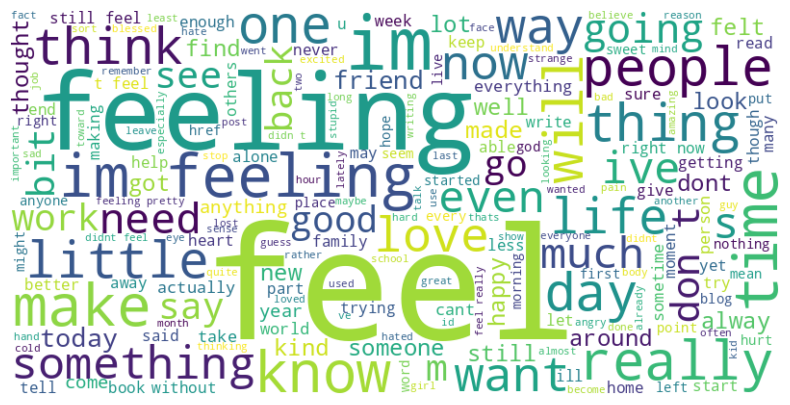

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(df["text"].astype(str))

wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()